# Step 4: Training a Deep Q-Network (DQN) Agent

This is the final and most important step. We will train a Deep Q-Network (DQN) agent to master our custom `TaxiDispatchEnvV3` environment.

A DQN uses a neural network to approximate the Q-function, which allows it to handle the enormous state space of our complex environment.

This notebook contains:
1.  **Replay Buffer**: A class to store and sample the agent's experiences.
2.  **DQN Agent**: A class that defines the neural network architecture and the learning algorithm.
3.  **Training Loop**: The main script to run the simulation and train the agent.
4.  **Visualization**: Code to plot the agent's performance.

**Note**: This notebook requires PyTorch. If you don't have it installed, you will need to install it.

In [1]:
# It's recommended to run this in your terminal if you don't have PyTorch
# %pip install torch torchvision torchaudio
# %pip install tqdm

import torch
import numpy as np
import pandas as pd
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import our refactored classes
from src.environment import TaxiDispatchEnvV3
from src.agent import DQNAgent

# Set a random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


## 1. Setup Environment and Agent

Now that our `TaxiDispatchEnvV3` and `DQNAgent` classes are neatly organized in the `src` directory, we can simply import them.

This notebook now serves as the main "driver" script. It's responsible for:
1.  Instantiating the environment and the agent.
2.  Running the training loop.
3.  Evaluating the agent's performance against a baseline.
4.  Visualizing the results.


In [2]:
# --- Hyperparameters ---
NUM_TAXIS = 50
DATA_PATH = 'data/yellow_tripdata_2025-01_manhattan.parquet'
MATRIX_PATH = 'data/travel_matrix.parquet'
EPISODE_LENGTH = 250 # Number of dispatch decisions per episode

# --- Environment and Agent Initialization ---
env = TaxiDispatchEnvV3(
    num_taxis=NUM_TAXIS,
    data_path=DATA_PATH,
    matrix_path=MATRIX_PATH,
    episode_length=EPISODE_LENGTH
)

# We need to know the number of unique locations for the DQN input layer
num_locations = len(env.unique_locations)

# Initialize DQN Agent
agent = DQNAgent(
    num_taxis=NUM_TAXIS,
    num_locations=num_locations,
    seed=seed
)


## 2. Train the DQN Agent

Here is the main training loop. We'll train for a set number of episodes and use a decaying epsilon-greedy strategy for exploration.


Episode 100 | Avg Score: 1472.43:   5%|▌         | 100/2000 [01:24<28:42,  1.10it/s]

\rEpisode 100\tAverage Score: 1472.43


Episode 200 | Avg Score: 1637.21:  10%|█         | 200/2000 [03:00<29:44,  1.01it/s]

\rEpisode 200\tAverage Score: 1637.21


Episode 300 | Avg Score: 1738.09:  15%|█▌        | 300/2000 [04:41<29:37,  1.05s/it]

...

\rEpisode 1800\tAverage Score: 1972.79


Episode 1900 | Avg Score: 1977.86:  95%|█████████▌| 1900/2000 [34:05<01:54,  1.15s/it]

\rEpisode 1900\tAverage Score: 1977.86


Episode 2000 | Avg Score: 1966.91: 100%|██████████| 2000/2000 [35:55<00:00,  1.08s/it]

\rEpisode 2000\tAverage Score: 1966.91


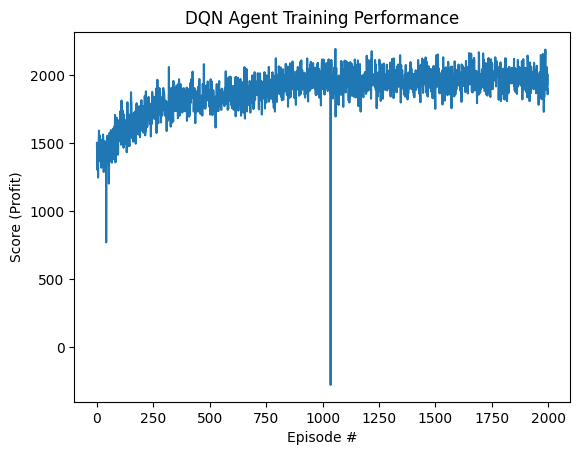

In [3]:
def train_dqn(n_episodes=2000, max_t=EPISODE_LENGTH, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    """
    Main training loop for the DQN agent.
    
    Params
    ======
        n_episodes (int): maximum number of training episodes
        max_t (int): maximum number of timesteps per episode
        eps_start (float): starting value of epsilon, for epsilon-greedy action selection
        eps_end (float): minimum value of epsilon
        eps_decay (float): multiplicative factor (per episode) for decreasing epsilon
    """
    scores = []                        # list containing scores from each episode
    scores_window = deque(maxlen=100)  # last 100 scores
    eps = eps_start                    # initialize epsilon
    
    pbar = tqdm(range(1, n_episodes + 1))
    for i_episode in pbar:
        state, _ = env.reset()
        score = 0
        for t in range(max_t):
            action = agent.act(state, eps)
            next_state, reward, done, _, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            score += reward
            if done:
                break 
        
        scores_window.append(score)
        scores.append(score)
        
        eps = max(eps_end, eps_decay * eps) # decrease epsilon
        
        # Update the learning rate
        agent.scheduler.step()
        
        pbar.set_description(f"Episode {i_episode} | Avg Score: {np.mean(scores_window):.2f}")
        
        if i_episode % 100 == 0:
            print(f'\\rEpisode {i_episode}\\tAverage Score: {np.mean(scores_window):.2f}')
            
    # Save the trained model
    torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
    return scores

# --- Start Training ---
scores = train_dqn()

# --- Visualize Results ---
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score (Profit)')
plt.xlabel('Episode #')
plt.title('DQN Agent Training Performance')
plt.show()


## 3. Evaluate Agent Against a Baseline

Training is not enough. We need to prove our agent is better than a simple, naive strategy. Here, we'll define two baseline agents:

1.  **Random Agent**: Dispatches a random available taxi for every request.
2.  **Closest Agent**: A heuristic agent that always dispatches the taxi with the shortest "deadhead" distance to the pickup location.

We will run a series of evaluation episodes for our trained DQN agent and the baselines, then compare their performance on key metrics.


Evaluating ClosestAgent: 100%|██████████| 500/500 [07:24<00:00,  1.12it/s]

\n--- Evaluation Results ---
DQN Agent Average Profit: $1981.17
Closest Taxi Agent Average Profit: $2223.34
Random Agent Average Profit: $1418.63



/var/folders/c5/09trk0mj389dhs59ptvs9f8h0000gn/T/ipykernel_32375/32913443.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dqn_rewards, closest_rewards, random_rewards], labels=['DQN Agent', 'Closest Taxi', 'Random'])


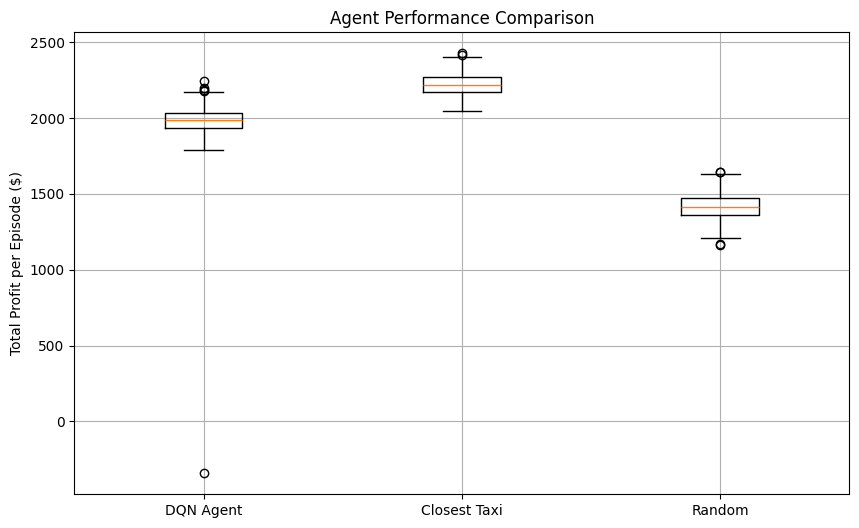

In [4]:
def evaluate_agent(agent, env, n_episodes=100, is_dqn=False):
    """Runs an agent through the environment and returns total rewards."""
    total_rewards = []
    
    for i in tqdm(range(n_episodes), desc=f"Evaluating {agent.__class__.__name__}"):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            if is_dqn:
                # DQN agent uses its learned policy (no exploration)
                action = agent.act(state, eps=0.0)
            else:
                # Baseline agents have a different act method signature
                action = agent.act(state)
                
            next_state, reward, done, _, _ = env.step(action)
            episode_reward += reward
            state = next_state
            
        total_rewards.append(episode_reward)
        
    return total_rewards

class RandomAgent:
    """A baseline agent that chooses actions randomly."""
    def __init__(self, num_taxis):
        self.num_taxis = num_taxis
        
    def act(self, state):
        return random.choice(np.arange(self.num_taxis))

class ClosestAgent:
    """A heuristic agent that chooses the closest taxi."""
    def __init__(self, env):
        self.env = env

    def act(self, state):
        taxi_locs = state['taxis']
        request_origin = state['request']['origin']
        day = state['time']['day_of_week']
        hour = state['time']['hour_of_day']
        
        min_dist = float('inf')
        best_taxi = -1
        
        for i, taxi_loc_idx in enumerate(taxi_locs):
            # Convert index back to LocationID for the travel cost function
            taxi_loc_id = self.env.inverse_location_map[taxi_loc_idx]
            request_origin_id = self.env.inverse_location_map[request_origin]
            
            dist = self.env._get_travel_cost(taxi_loc_id, request_origin_id, day, hour)
            
            if dist < min_dist:
                min_dist = dist
                best_taxi = i
                
        return best_taxi

# --- Initialize Baseline Agents ---
random_agent = RandomAgent(NUM_TAXIS)
closest_agent = ClosestAgent(env) # Needs env to access the travel matrix

# --- Load the Trained DQN Agent ---
# Make sure to load the state dict into a fresh agent instance
trained_agent = DQNAgent(num_taxis=NUM_TAXIS, num_locations=num_locations, seed=seed)
trained_agent.qnetwork_local.load_state_dict(torch.load('checkpoint.pth'))

# --- Run Evaluation ---
dqn_rewards = evaluate_agent(trained_agent, env, n_episodes=500, is_dqn=True)
random_rewards = evaluate_agent(random_agent, env, n_episodes=500)
closest_rewards = evaluate_agent(closest_agent, env, n_episodes=500)

# --- Print and Plot Results ---
print(f"\\n--- Evaluation Results ---")
print(f"DQN Agent Average Profit: ${np.mean(dqn_rewards):.2f}")
print(f"Closest Taxi Agent Average Profit: ${np.mean(closest_rewards):.2f}")
print(f"Random Agent Average Profit: ${np.mean(random_rewards):.2f}")

# Create a boxplot to compare distributions
plt.figure(figsize=(10, 6))
plt.boxplot([dqn_rewards, closest_rewards, random_rewards], labels=['DQN Agent', 'Closest Taxi', 'Random'])
plt.ylabel('Total Profit per Episode ($)')
plt.title('Agent Performance Comparison')
plt.grid(True)
plt.show()


In [5]:
# --- Hyperparameters ---
NUM_TAXIS = 5
DATA_PATH = 'data/yellow_tripdata_2025-01_manhattan.parquet'
MATRIX_PATH = 'data/travel_matrix.parquet'
EPISODE_LENGTH = 50
INITIAL_LR = 5e-4

# --- Instantiate Environment and Agent ---
env = TaxiDispatchEnvV3(num_taxis=NUM_TAXIS, data_path=DATA_PATH, matrix_path=MATRIX_PATH, episode_length=EPISODE_LENGTH)
agent = DQNAgent(num_taxis=NUM_TAXIS, num_locations=len(env.unique_locations), seed=0, initial_lr=INITIAL_LR)

# --- Training ---
n_episodes = 2000
max_t = EPISODE_LENGTH # Set max_t to the episode length
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

scores = []
scores_window = deque(maxlen=100)
eps = eps_start
best_avg_score = -np.inf # Initialize with a very low value

for i_episode in tqdm(range(1, n_episodes+1)):
    state, _ = env.reset()
    score = 0
    for t in range(max_t):
        action = agent.act(state, eps)
        next_state, reward, done, _, _ = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        score += reward
        if done:
            break 
    scores_window.append(score)
    scores.append(score)
    eps = max(eps_end, eps_decay*eps)
    
    # Take a step with the learning rate scheduler
    agent.scheduler.step()
    
    current_avg_score = np.mean(scores_window)
    
    if i_episode % 100 == 0:
        print(f'\rEpisode {i_episode}\tAverage Score: {current_avg_score:.2f}')
        
    # Save the best model
    if current_avg_score > best_avg_score and len(scores_window) >= 100:
        print(f'New best average score of {current_avg_score:.2f} achieved at episode {i_episode}! Saving model...')
        torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
        best_avg_score = current_avg_score


print(f'Training complete. Best average score: {best_avg_score:.2f}')

  0%|          | 0/2000 [00:00<?, ?it/s]/Users/zak/anaconda3/envs/DataCamp/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
  5%|▌         | 104/2000 [00:04<01:21, 23.30it/s]

Episode 100	Average Score: 290.10
New best average score of 290.10 achieved at episode 100! Saving model...
New best average score of 290.31 achieved at episode 101! Saving model...
New best average score of 291.11 achieved at episode 103! Saving model...
New best average score of 291.12 achieved at episode 104! Saving model...


  5%|▌         | 107/2000 [00:04<01:21, 23.10it/s]

New best average score of 291.80 achieved at episode 105! Saving model...
New best average score of 292.84 achieved at episode 106! Saving model...
New best average score of 292.97 achieved at episode 107! Saving model...
New best average score of 293.20 achieved at episode 108! Saving model...
New best average score of 293.37 achieved at episode 109! Saving model...


  6%|▌         | 113/2000 [00:04<01:21, 23.03it/s]

...

Episode 1800	Average Score: 358.86


 95%|█████████▌| 1904/2000 [01:34<00:04, 20.02it/s]

Episode 1900	Average Score: 352.36


100%|██████████| 2000/2000 [01:39<00:00, 20.10it/s]

Episode 2000	Average Score: 353.47
Training complete. Best average score: 361.26


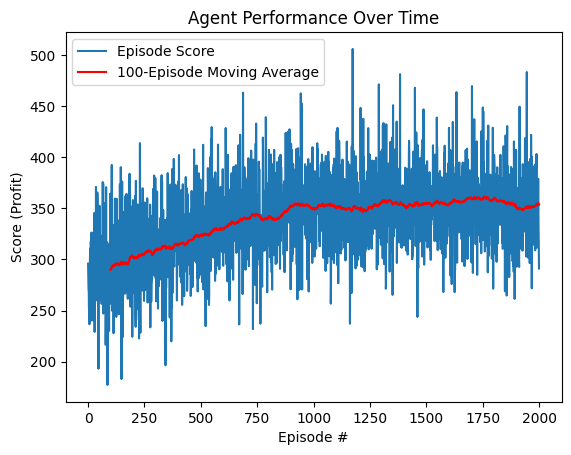

In [6]:
# Plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot raw scores
plt.plot(np.arange(len(scores)), scores, label='Episode Score')

# Calculate and plot 100-episode moving average
moving_avg = pd.Series(scores).rolling(100).mean()
plt.plot(moving_avg.index, moving_avg.values, color='red', label='100-Episode Moving Average')

plt.ylabel('Score (Profit)')
plt.xlabel('Episode #')
plt.title('Agent Performance Over Time')
plt.legend()
plt.show()